
# Olympic medals → a rolling‑window ranking race of nations, recoloured by rank
### A hands‑on project with **gradient‑sankey** — built *com todo cuidado e carinho* 💙

Welcome! 👋 This lesson tells one of the great sports stories in data: **120 years of Olympic
medals**, from **Athens 1896 → Rio 2016**, as a **ranking race of nations**. A 2‑column Sankey flows
**country → medal** (Gold / Silver / Bronze); ribbon width is the **number of medals**; and **every
frame is one Summer Games**. The left (country) column is **recoloured every frame by live rank**
(#1 = hot), while the right column keeps the honest Gold / Silver / Bronze tones.

> If you've done `07_tutorial_br_fiscal.ipynb` or the refugees lesson, the **dynamic rank colouring**
> will feel familiar — but this lesson adds **two** data‑integrity twists that are the whole point:
> the raw table has **one row per athlete per event** (team sports would massively over‑count), and
> dissolved states (the **USSR**, the **two Germanys**) would otherwise *vanish or split* mid‑race.
> We fix both — with a single load‑bearing **de‑duplication** and a small **NOC‑stitching** map.

---

### What we'll build

A **stacked ranking race** with two columns: on the **left**, the **top‑10 nations** (USA, URS/RUS,
GBR, GER, …) — *the racers*, recoloured every frame by their **live rank**; on the **right**, the three
**medals** (Gold / Silver / Bronze) in their metallic tones. Crucially the bars carry a **rolling
2‑Games window** (≈ "current form"), **not** an all‑time tally — so the race actually **moves**: you
watch the Cold‑War **USA ↔ USSR** duel, the **USSR vanish** after 1991, and **China surge** after 2008.

### Learning outcomes

1. Load the free **"120 years of Olympic history"** dataset (one public CSV, no key) and understand
   its **one‑row‑per‑athlete‑per‑event** grain.
2. **The headline lesson:** *why* counting rows over‑counts team sports, and how a single
   **`drop_duplicates(["Games","Event","Medal","NOC"])`** gives one *physical* medal per event —
   **verified against a known fact** (USA all‑time Summer golds ≈ 1,000, total ≈ 2,500).
3. **Stitch** dissolved/renamed states (USSR→Russia, the two Germanys) so a nation's line never gaps.
4. Build a **rolling 2‑Games window** (and understand *why not cumulative*).
5. Keep only the **top‑10** nations (`drop_others`) for a focused great‑power race.
6. Drive `gradient_sankey` with **`dynamic_color_mode="ranking"`**, **`fixed_color_nodes`** (metallic
   medals stay off the rank ramp), **`annotations`** + **`hold_periods`** (beat captions & pauses on
   1980/1984/1992/2008), the medal‑count axis, and the **growth overlay** with `overlay_band`.

> **This notebook is fully self‑contained.** It clones‑and‑runs from the gradient‑sankey repo: it
> imports only `gradient_sankey` (the committed module at the repo root), the Python standard library,
> and `pandas`. Every download and every helper is **inlined below as a teaching step**, so you can
> read the whole ETL pipeline end to end. 💙



## 1 · Setup & install

The library lives in this repo as a single module, `gradient_sankey.py`, at the **repo root**. We add
the repo root to `sys.path` so we always get the **local** copy with the newest features:

```bash
pip install gradient-sankey pandas      # the public packages
# this notebook uses the LOCAL repo copy of gradient_sankey via sys.path (see below)
```

> ⚠️ **Heads‑up — newest features.** This reel leans on capabilities in `gradient_sankey.py` that may
> be newer than the pinned PyPI release:
> - **`dynamic_color_mode="ranking"`** with a **`dynamic_colormap`** — recolour every nation by its
>   live rank each frame (the cinematic heart of this lesson),
> - **`fixed_color_nodes`** — keep the three medals **metallic** (off the rank ramp) while only the
>   nations race‑recolour,
> - **`annotations`** (a per‑Games caption) and **`hold_periods`** (linger on a Games),
> - the **layer‑total value axis** (`yaxis_node`) with **`value_prefix=""`** (medals, not dollars),
>   plus **`yaxis_gap`**, **`layer0_label_side`** and the **`overlay_band`** control.
>
> Importing the local module via `sys.path` (below) makes all of these work today. 🎁

We only need `pandas` for the data (plus the standard library to fetch the CSV), and the library for
the visuals. Rendering an **MP4** also needs **FFmpeg** on your PATH — but the still frames
(`save_frame`) need nothing extra, so the notebook stays runnable even without FFmpeg.


In [1]:
import os, sys, pathlib, urllib.request

# --- import the LOCAL gradient_sankey from the repo root (committed module) ---
# This notebook lives in notebooks/, so the repo root is one level up.
REPO_ROOT = os.path.abspath("..")          # notebooks/  ->  repo root
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import pandas as pd
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

# where we'll drop the rendered stills / sample clip (kept out of the repo root)
ASSETS = os.path.abspath("gallery_assets"); os.makedirs(ASSETS, exist_ok=True)

# a LOCAL, gitignored cache for the one CSV download, so a re-run is instant.
# (Re-fetching from GitHub on a clean run is fine.)
CACHE = pathlib.Path(os.path.abspath(".nbcache")); CACHE.mkdir(parents=True, exist_ok=True)

def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)
print("pandas:", pd.__version__)
print("cache ->", CACHE)


gradient-sankey version: 1.2.2
pandas: 3.0.1
cache -> C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\.nbcache



## 2 · A 2‑minute primer — and the *one‑row‑per‑athlete* trap

The classic **["120 years of Olympic history"](https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results)**
dataset (`athlete_events.csv`, scraped from sports‑reference.com) covers every modern Games from
**Athens 1896 → Rio 2016**. It's a single CSV — no API key, no auth — mirrored on GitHub:

```
https://raw.githubusercontent.com/Thomas-George-T/Olympic-History-Analytics-in-R/main/athlete_events.csv
```

It has **271,116 rows × 15 columns**. The columns we care about:

| Column | Meaning |
|---|---|
| `Year`, `Season`, `Games`, `City` | when/which edition (`Games` = e.g. `"1992 Summer"`) |
| `NOC` | the country (National Olympic Committee 3‑letter code, e.g. `USA`, `URS`, `CHN`) |
| `Sport`, `Event` | the discipline and the specific event |
| `Medal` | `Gold` / `Silver` / `Bronze`, or **`NaN`** for the (vast) majority who didn't medal |

> ### ⚠️ The grain trap — *one row per athlete per event*
> This is the single most important thing to understand about this dataset. **Each row is one
> athlete in one event.** So a **basketball** gold is **12 rows** (one per player), a **4×100 m
> relay** gold is **4+ rows**, an **ice‑hockey** gold is **~16 rows**. If you just count medal rows,
> **team sports explode** and a basketball gold counts as much as twelve swimming golds. 🏀💥
>
> The fix is a single **de‑duplication**: collapse to **one row per `(Games, Event, Medal, NOC)`** —
> i.e. one *physical* medal per event‑placing. We keep `NOC` in the key so the rare events that award
> **two bronzes to different countries** (boxing, judo, wrestling) still count **both** nations. We'll
> **verify** the fix against a known fact below.



## 3 · Load the CSV (cached) and *see* the over‑count trap

One download (~40 MB) from the public GitHub‑raw URL, cached to our local `.nbcache/` so a re‑run is
instant. Then we make the trap **concrete** by contrasting the naive row‑count with the de‑duplicated
count for a famously *team‑heavy* result.


In [2]:
OLYMPICS_URL = ("https://raw.githubusercontent.com/Thomas-George-T/"
                "Olympic-History-Analytics-in-R/main/athlete_events.csv")

def load_olympics():
    """Download (disk-cached) the 120-years athlete_events CSV from the public GitHub raw URL."""
    cf = CACHE / "athlete_events.csv"
    if not cf.exists():
        print("downloading athlete_events.csv (~40 MB) from GitHub raw ...")
        urllib.request.urlretrieve(OLYMPICS_URL, cf)
    return pd.read_csv(cf)

raw = load_olympics()
print("rows x cols:", raw.shape)
print("seasons:", list(raw.Season.unique()))
print("medals :", list(pd.Series(raw.Medal.unique()).dropna()))
raw[["Year","Season","NOC","Sport","Event","Medal"]].head(5)


rows x cols: (271116, 15)


seasons: ['Summer', 'Winter']
medals : ['Gold', 'Bronze', 'Silver']


,Year,Season,NOC,Sport,Event,Medal
0,1992,Summer,CHN,Basketball,Basketball Men's Basketball,NaN
1,2012,Summer,CHN,Judo,Judo Men's Extra-Lightweight,NaN
2,1920,Summer,DEN,Football,Football Men's Football,NaN
3,1900,Summer,DEN,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,1988,Winter,NED,Speed Skating,Speed Skating Women's 500 metres,NaN



Here is the trap in **two numbers**. Take the **USA men's basketball gold at Rio 2016**: as *rows*
it's the whole roster; as *medals* it's exactly **one**. Watch.


In [3]:
bball = raw[(raw.Games == "2016 Summer") & (raw.NOC == "USA") &
            (raw.Event == "Basketball Men's Basketball") & (raw.Medal == "Gold")]
print("USA men's basketball GOLD, Rio 2016:")
print(f"  naive medal ROWS  : {len(bball)}   <- one per player (over-counts!)")
print(f"  actual medals won : 1   <- it is ONE gold medal")
print("\nThe whole roster, all tagged 'Gold' (each would be double-counted):")
display(bball[["Name", "NOC", "Event", "Medal"]].reset_index(drop=True))


USA men's basketball GOLD, Rio 2016:
  naive medal ROWS  : 12   <- one per player (over-counts!)
  actual medals won : 1   <- it is ONE gold medal

The whole roster, all tagged 'Gold' (each would be double-counted):


,Name,NOC,Event,Medal
0,Carmelo Kyan Anthony,USA,Basketball Men's Basketball,Gold
1,Harrison Bryce Jordan Barnes,USA,Basketball Men's Basketball,Gold
2,Jimmy Butler III,USA,Basketball Men's Basketball,Gold
3,DeMarcus Amir Cousins,USA,Basketball Men's Basketball,Gold
4,DeMar Darnell DeRozan,USA,Basketball Men's Basketball,Gold
5,Kevin Wayne Durant,USA,Basketball Men's Basketball,Gold
6,Paul George,USA,Basketball Men's Basketball,Gold
7,Draymond Jamal Green,USA,Basketball Men's Basketball,Gold
8,Kyrie Andrew Irving,USA,Basketball Men's Basketball,Gold
9,"Hyland DeAndre Jordan, Jr.",USA,Basketball Men's Basketball,Gold



## 4 · The de‑duplication (the heart of this lesson) 🔑 — and a verified sanity check

Now the fix. We:
1. **drop the non‑medal rows** (`Medal` is `NaN` for everyone who didn't place),
2. restrict to one **season** (we tell the Summer story),
3. **`drop_duplicates(["Games","Event","Medal","NOC"])`** — collapsing each team roster to **one
   physical medal per event‑place**,
4. group to a tidy medal table `[Year, NOC, Medal, n]`.

Then we **prove it's right**: the USA's all‑time **Summer golds** should be **≈ 1,000** and total
Summer medals **≈ 2,500** — the well‑known figures. If our de‑dup were wrong (e.g. counting rows),
these would be wildly inflated.


In [4]:
SEASON = "Summer"     # the Summer story (Athens 1896 -> Rio 2016)

m = raw[(raw.Season == SEASON) & raw.Medal.notna()].copy()
print(f"{SEASON} medal ROWS (athlete-event, pre-dedup): {len(m):,}")

# THE de-dup: one physical medal per (Games, Event, Medal, NOC)
m = m.drop_duplicates(subset=["Games", "Event", "Medal", "NOC"])
print(f"{SEASON} medals after de-dup (one per event-place): {len(m):,}")

# tidy medal table: one row per (Year, NOC, Medal) with a count
medal_tab = m.groupby(["Year", "NOC", "Medal"]).size().rename("n").reset_index()
print(f"\ntidy medal table: {len(medal_tab):,} [Year, NOC, Medal, n] rows, "
      f"{medal_tab.Year.min()}-{medal_tab.Year.max()}")

# --- VERIFY against a known fact: USA all-time Summer golds (~1000) and total (~2500) ---
usa = medal_tab[medal_tab.NOC == "USA"]
usa_gold  = int(usa[usa.Medal == "Gold"]["n"].sum())
usa_total = int(usa["n"].sum())
print(f"\nSANITY CHECK — USA all-time {SEASON} medals (de-duplicated):")
print(f"  golds = {usa_gold}   total = {usa_total}")
print(f"  (known figures: ~1,000 Summer golds, ~2,500 total -> our de-dup is correct ✅)")
assert 950 <= usa_gold <= 1100 and 2400 <= usa_total <= 2700, "de-dup looks wrong!"
medal_tab.head(6)


Summer medal ROWS (athlete-event, pre-dedup): 34,088


Summer medals after de-dup (one per event-place): 16,052

tidy medal table: 2,809 [Year, NOC, Medal, n] rows, 1896-2016



SANITY CHECK — USA all-time Summer medals (de-duplicated):
  golds = 1035   total = 2544
  (known figures: ~1,000 Summer golds, ~2,500 total -> our de-dup is correct ✅)


,Year,NOC,Medal,n
0,1896,AUS,Bronze,1
1,1896,AUS,Gold,2
2,1896,AUT,Bronze,2
3,1896,AUT,Gold,2
4,1896,AUT,Silver,1
5,1896,DEN,Bronze,3



## 5 · Stitch the dissolved states so no nation *vanishes* mid‑race 🧵

A 120‑year race spans the **rise and fall of whole countries**. If we leave the raw NOC codes alone, a
nation's line can **gap, split or disappear** for reasons of *politics*, not sport:

- the **Soviet Union** (`URS`) competes 1952–1988, becomes the **Unified Team** (`EUN`) in 1992, then
  **Russia** (`RUS`) — three codes, **one** continuous story;
- **Germany** splits into **East** (`GDR`) and **West** (`FRG`) for 1968–1988, then re‑merges as
  unified **Germany** (`GER`).

So we apply a tiny **NOC‑merge** map (exactly `olympics_reel.NOC_MERGE`) **before** building the race,
collapsing those codes into one continuous entity. This way you watch the **post‑1991 collapse** of the
Soviet line — not a confusing *disappearance*.

> 🧭 **An honesty note.** Fusing `GDR`+`FRG` into one "Germany" deliberately folds the GDR‑doping era
> into the German line — a defensible simplification for a *continuity* race, but a different reel could
> keep them distinct. We name the merged Soviet/Russian line `URS/RUS` so the label says exactly what
> it is.


In [5]:
# Stitch dissolved/renamed states into one continuous entity (matches olympics_reel.NOC_MERGE)
NOC_MERGE = {
    "URS": "URS/RUS", "EUN": "URS/RUS", "RUS": "URS/RUS",   # Soviet Union -> Unified Team -> Russia
    "GDR": "GER", "FRG": "GER",                             # East + West Germany -> Germany
    "TCH": "CZE", "CZE": "CZE",                             # Czechoslovakia -> Czechia
}

before = medal_tab["NOC"].nunique()
medal_tab["NOC"] = medal_tab["NOC"].replace(NOC_MERGE)
# re-aggregate: the merged codes must now sum together within each (Year, Medal)
medal_tab = medal_tab.groupby(["Year", "NOC", "Medal"], as_index=False)["n"].sum()
after = medal_tab["NOC"].nunique()
print(f"NOC codes: {before} -> {after} after stitching (USSR/Unified/Russia & the two Germanys merged)")

# show the stitched Soviet/Russian line straddling the 1991 collapse
urs = (medal_tab[medal_tab.NOC == "URS/RUS"].groupby("Year")["n"].sum())
print("\nURS/RUS medals per Games (one continuous line across the USSR -> Russia transition):")
display(urs.loc[urs.index >= 1980].to_frame("medals").T)


NOC codes: 147 -> 142 after stitching (USSR/Unified/Russia & the two Germanys merged)

URS/RUS medals per Games (one continuous line across the USSR -> Russia transition):


Year,1980,1988,1992,1996,2000,2004,2008,2012,2016
medals,195,131,112,63,89,90,72,82,56



## 6 · Keep the **top‑10** nations (drop the long tail) 🎯

A 120‑year medal table still has **~140 NOCs** — far too many for a readable race, and the long tail of
small nations would otherwise pile into a single "Others" node that reads as fragmented noise. For this
reel we instead **drop the long tail entirely** (`drop_others=True` in `olympics_flows`) and keep only
the **top‑10** nations by **all‑time total medals** — a focused **great‑power** medal race.

> Identity stays **all‑time**, so the *same* ten nations are tracked throughout; their bars then rise
> and fall by era under the rolling window we build next (e.g. `URS/RUS` appears in 1952, dominates,
> then fades after 1991).


In [6]:
TOP = 10      # top-N nations by all-time total medals; the long tail is DROPPED (no 'Others')

tot_by_noc = medal_tab.groupby("NOC")["n"].sum().sort_values(ascending=False)
top_nocs = tot_by_noc.head(TOP).index.tolist()
print(f"Top {TOP} {SEASON} nations (all-time total medals, after stitching):")
for noc in top_nocs:
    print(f"  {noc:>8}  {int(tot_by_noc[noc]):>5}")

# drop_others: keep ONLY the top-N nations (no 'Others' bucket)
medal_tab = medal_tab[medal_tab["NOC"].isin(top_nocs)].copy()
medal_tab["country"] = medal_tab["NOC"]
print(f"\nkept {len(top_nocs)} nations; long tail of "
      f"{after - TOP} smaller NOCs DROPPED for a focused great-power race")


Top 10 Summer nations (all-time total medals, after stitching):
       USA   2544
   URS/RUS   1577
       GER   1389
       GBR    892
       FRA    770
       ITA    608
       CHN    542
       SWE    513
       AUS    506
       HUN    504

kept 10 nations; long tail of 132 smaller NOCs DROPPED for a focused great-power race



## 7 · A **rolling 2‑Games window** — *why not cumulative?* 🔄

Here's the design decision that makes this reel *move*. The obvious choice is a **cumulative** all‑time
tally — but a running total can **only ever grow**, so the leaderboard barely changes and the late
Games are a flat, monotonic landslide. **None of the actual history shows up.**

Instead we use a **rolling window**: each nation's bar is the medals it won over the **last `roll`
Games** (`roll = 2` ≈ an **~8‑year "current form"** window). Now the race breathes:

- the **Cold‑War USA ↔ USSR duel** swings back and forth,
- the **USSR line collapses** after 1991 (a cumulative tally would *freeze* it at its peak forever),
- **China surges** after 2008, host nations get a **bump**, boycotts a **dip**.

Two `pandas` steps make it well‑defined:
1. **Make the table dense** over every `(Games‑year, country, medal)` so a Games a nation *skipped*
   counts as a **0** — which the rolling window must see (otherwise the window slides over the wrong
   Games).
2. A **`rolling(roll).sum()`** over the *Games sequence* (not calendar years — the World‑War gaps are
   simply absent from the list of Games).

This is the (default, non‑cumulative) branch of `olympics_flows`.


In [7]:
MEDALS = ["Gold", "Silver", "Bronze"]
ROLL   = 2     # rolling window in GAMES (~8-yr current form); NOT cumulative
years  = sorted(medal_tab["Year"].unique())

# collapse to [year, country, medal, value]
g = (medal_tab.groupby(["Year", "country", "Medal"])["n"].sum()
     .rename("value").reset_index()
     .rename(columns={"Year": "year", "Medal": "medal"}))

# (1) make DENSE over every (year, country, medal) so a skipped Games counts as 0
idx = pd.MultiIndex.from_product(
    [years, sorted(g["country"].unique()), MEDALS],
    names=["year", "country", "medal"])
g = (g.set_index(["year", "country", "medal"])["value"]
     .reindex(idx, fill_value=0).reset_index().sort_values("year"))

# (2) ROLLING sum over the last ROLL Games (the Games sequence, not calendar years)
g["value"] = (g.groupby(["country", "medal"])["value"]
              .transform(lambda s: s.rolling(ROLL, min_periods=1).sum()))
df = g[g["value"] > 0].copy()            # drop zero-width (undrawable) ribbons

print(f"{len(df)} tidy rolling-{ROLL}-Games [year, country, medal, value] rows")
# the leaderboard at the final Games (current-form, last 2 Games) — USA should lead
final = (df[df.year == years[-1]]
         .groupby("country")["value"].sum().sort_values(ascending=False))
print(f"\nCurrent-form (last {ROLL} Games) leaderboard at {years[-1]}:")
display(final.to_frame("medals_window"))


758 tidy rolling-2-Games [year, country, medal, value] rows

Current-form (last 2 Games) leaderboard at 2016:


,medals_window
country,
USA,224.0
CHN,158.0
URS/RUS,138.0
GBR,132.0
GER,86.0
FRA,77.0
AUS,64.0
ITA,56.0
HUN,33.0



## 8 · Layers and colours

Two layers: **nations on the left** (the racers), **medals on the right**. The country base colours are
**placeholders** — `dynamic_color_mode="ranking"` will repaint each by its live rank every frame. The
medals keep **honest, metallic, meaning‑carrying tones** (gold / silver / bronze), and we'll keep them
**off the rank ramp** with `fixed_color_nodes` so only the nations race‑recolour. We order the left
column by all‑time total. This is the colour/layer block of `olympics_flows` + `olympics_reel`.


In [8]:
# medals keep honest metallic tones (matches olympics_reel.MEDAL_COLORS)
MEDAL_COLORS = {"Gold": "#FFD24A", "Silver": "#C7CDD4", "Bronze": "#CD7F4B"}

# left layer: nations by all-time total; right layer: the 3 medals
countries = [c for c in top_nocs if c in set(df["country"])]
medals = [m for m in MEDALS if m in set(df["medal"])]
LAYERS = [countries, medals]

# nation colours are placeholders (rank decides at render time); medals are fixed metallic
node_colors = {c: "#888888" for c in countries}
for mlbl, col in MEDAL_COLORS.items():
    node_colors[mlbl] = col

# keep the three medals OFF the rank ramp so only nations race-recolour
FIXED_COLOR_NODES = {"Gold", "Silver", "Bronze"}

print("countries (left):", countries)
print("medals    (right):", medals)
print("fixed (metallic, off-ramp):", sorted(FIXED_COLOR_NODES))


countries (left): ['USA', 'URS/RUS', 'GER', 'GBR', 'FRA', 'ITA', 'CHN', 'SWE', 'AUS', 'HUN']
medals    (right): ['Gold', 'Silver', 'Bronze']
fixed (metallic, off-ramp): ['Bronze', 'Gold', 'Silver']



## 9 · Beat captions, holds & the growth overlay 🎬

Four Summer moments are *the* story beats of this race. We surface them as on‑screen **`annotations`**
(a caption per Games) and **`hold_periods`** (a brief pause so the viewer can read it) — exactly the
`olympics_reel` choices:

| Year | Caption | Why it matters |
|---|---|---|
| **1980** | Moscow 1980 — US‑led boycott (USA win 0) | the USA's rolling line craters |
| **1984** | Los Angeles 1984 — Soviet‑bloc boycott | the mirror‑image dip for `URS/RUS` |
| **1992** | USSR dissolves → Unified Team, then Russia | the stitched Soviet line starts its collapse |
| **2008** | Beijing 2008 — China's home‑soil surge | `CHN` rockets up the board |

The footer chart is a line of the **total medals in the active window** (top‑10 nations), one point per
Games, tracking the great‑power field swelling and contracting under the shifting leaderboard.


In [9]:
# on-screen beat captions + brief pauses on the marquee Summer moments (olympics_reel choices)
annotations = {
    "1980": "Moscow 1980 — US-led boycott (USA win 0)",
    "1984": "Los Angeles 1984 — Soviet-bloc boycott",
    "1992": "USSR dissolves → Unified Team, then Russia",
    "2008": "Beijing 2008 — China's home-soil surge",
}
hold_periods = {"1980": 45, "1984": 30, "1992": 60, "2008": 45}   # frames (~1.5-2s @30fps)

total = [float(df[df.year == y]["value"].sum()) for y in years]   # medals in the active window per Games
xlabels = [str(y) for y in years]
print(f"medals in the active (last {ROLL} Games) window: "
      f"{total[0]:,.0f} ({years[0]}) -> {total[-1]:,.0f} ({years[-1]})")
print("\nbeat captions:")
for k, v in annotations.items():
    print(f"  {k}: {v}   (hold {hold_periods[k]} frames)")


medals in the active (last 2 Games) window: 62 (1896) -> 987 (2016)

beat captions:
  1980: Moscow 1980 — US-led boycott (USA win 0)   (hold 45 frames)
  1984: Los Angeles 1984 — Soviet-bloc boycott   (hold 30 frames)
  1992: USSR dissolves → Unified Team, then Russia   (hold 60 frames)
  2008: Beijing 2008 — China's home-soil surge   (hold 45 frames)



## 10 · Building the visual — every knob explained

We hand the tidy `df` + `LAYERS` to `from_dataframe`, then drive `animate()` with the reel's design.
Here's what each knob does in **this** reel — the exact settings from `olympics_reel`:

| Knob | Value | Why |
|---|---|---|
| `ranking_mode` | `True` | reorder nations/medals by value each frame — *the race* |
| `stacked_mode` | `True` | bar heights scale with medal count (biggest = tallest) |
| `dynamic_color_mode` | `"ranking"` ⚠️ | **repaint every nation by its live rank each frame** — the star |
| `dynamic_colormap` | `"autumn_r"` ⚠️ | the rank→colour map: **#1 = hot → last = cool** |
| `fixed_color_nodes` | `{Gold,Silver,Bronze}` ⚠️ | medals stay **metallic**, off the rank ramp |
| `theme` | `"dark"` | the neon‑on‑black reel look |
| `link_glow` / `link_alpha` | `1` / `0.6` | soft neon glow behind the ribbons |
| `yaxis_node` | `countries[0]` ⚠️ | a value axis scaled to the **leading nation's window total** |
| `yaxis_suffix` / `value_prefix` | `""` / `""` ⚠️ | ticks read like `120` — **medals, not dollars** |
| `annotations` / `hold_periods` | beats / pauses ⚠️ | the 1980/84/92/2008 captions & holds |
| `overlay_band` | `(0.18, 0.56)` ⚠️ | push the line chart **lower**, clear of the Sankey |

### How rank → colour actually works 🌈

With `dynamic_color_mode="ranking"`, on **every frame** the library ranks the visible nations by value,
maps each rank to a position in `[0, 1]` (**#1 → 0.0**, last → 1.0), and samples the `autumn_r`
colormap there. `autumn` runs yellow→red; the **`_r`** reverses it, so **#1 burns hot** and trailing
nations cool off. As China climbs the board after 2008, it *heats up on screen* — the colour **is** the
story. The three **medals stay metallic** because they're in `fixed_color_nodes`.

First, build the renderer — the single call that ingests everything.


In [10]:
sk = Sankey.from_dataframe(
    df=df, layers=LAYERS,
    time_col="year", source_col="country", target_col="medal", value_col="value",
    node_colors=node_colors,
)
anchor = countries[0]    # the leading nation anchors the medal-count axis
print(f"{len(sk.frames)} frames (Games):", sk.frames[0]['time_label'], "->", sk.frames[-1]['time_label'])
print("medal-count axis anchored on the country layer of:", anchor)


29 frames (Games): 1896 -> 2016
medal-count axis anchored on the country layer of: USA



## 11 · Render a short proof

Stills first — `save_frame()` needs **no FFmpeg**, so this always works. We render three Games that
bookend the story:

- **1976** — the Cold‑War peak (the USSR towers over a strong USA),
- **1980** — Moscow: the US‑led boycott craters the USA's rolling line,
- **2016** — the USA far ahead, China firmly in the top tier, the USSR line long gone.

> ⚠️ **One honest caveat about the stills.** `save_frame` is **static**, so it can't do the per‑frame
> **dynamic ranking colours** (those are computed *during* the animation). The stills therefore use our
> placeholder gray base colours for nations — they prove the **layout, axis, labels and ranking
> order**, while the **hot→cool rank colouring** only appears in the animated clip below. The
> medal‑count axis (`yaxis_node` + `value_prefix=""`) and `layer0_label_side` *do* work in stills.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\olympics_1976.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\olympics_1976.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\olympics_1980.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\olympics_1980.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\olympics_2016.png
saved C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\gallery_assets\olympics_2016.png


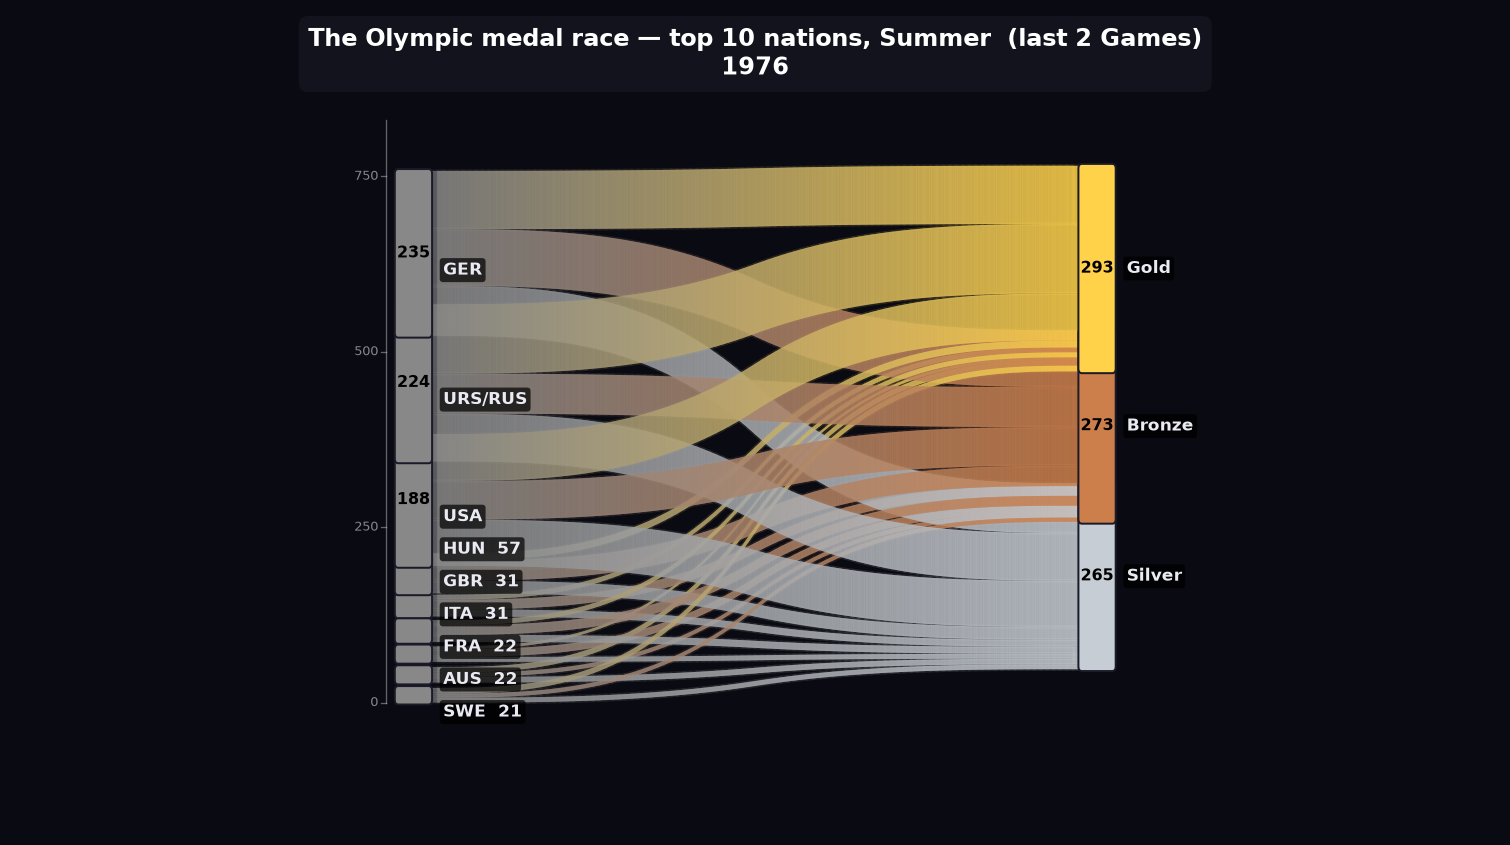

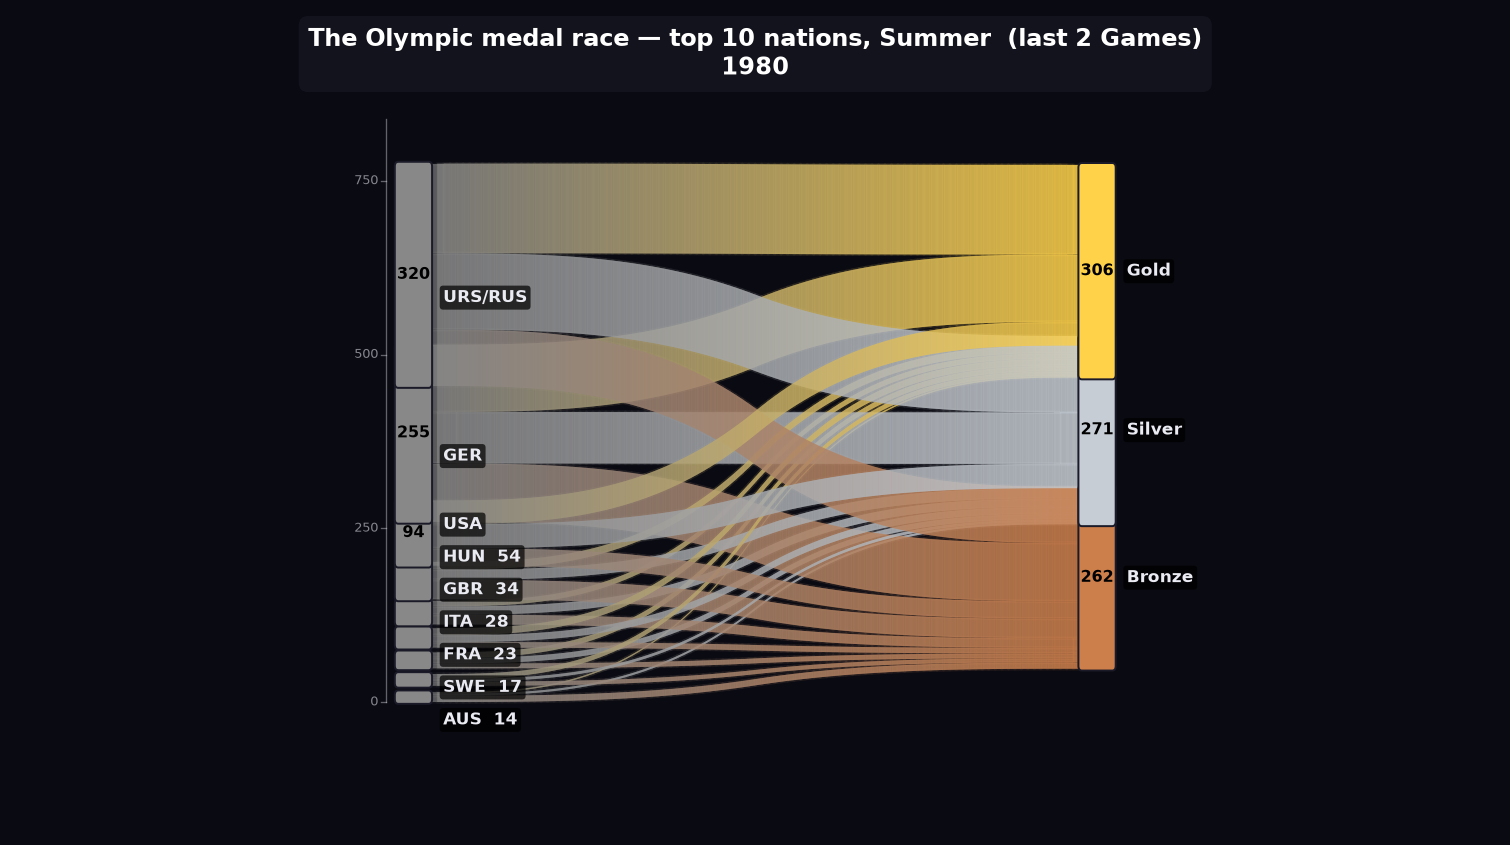

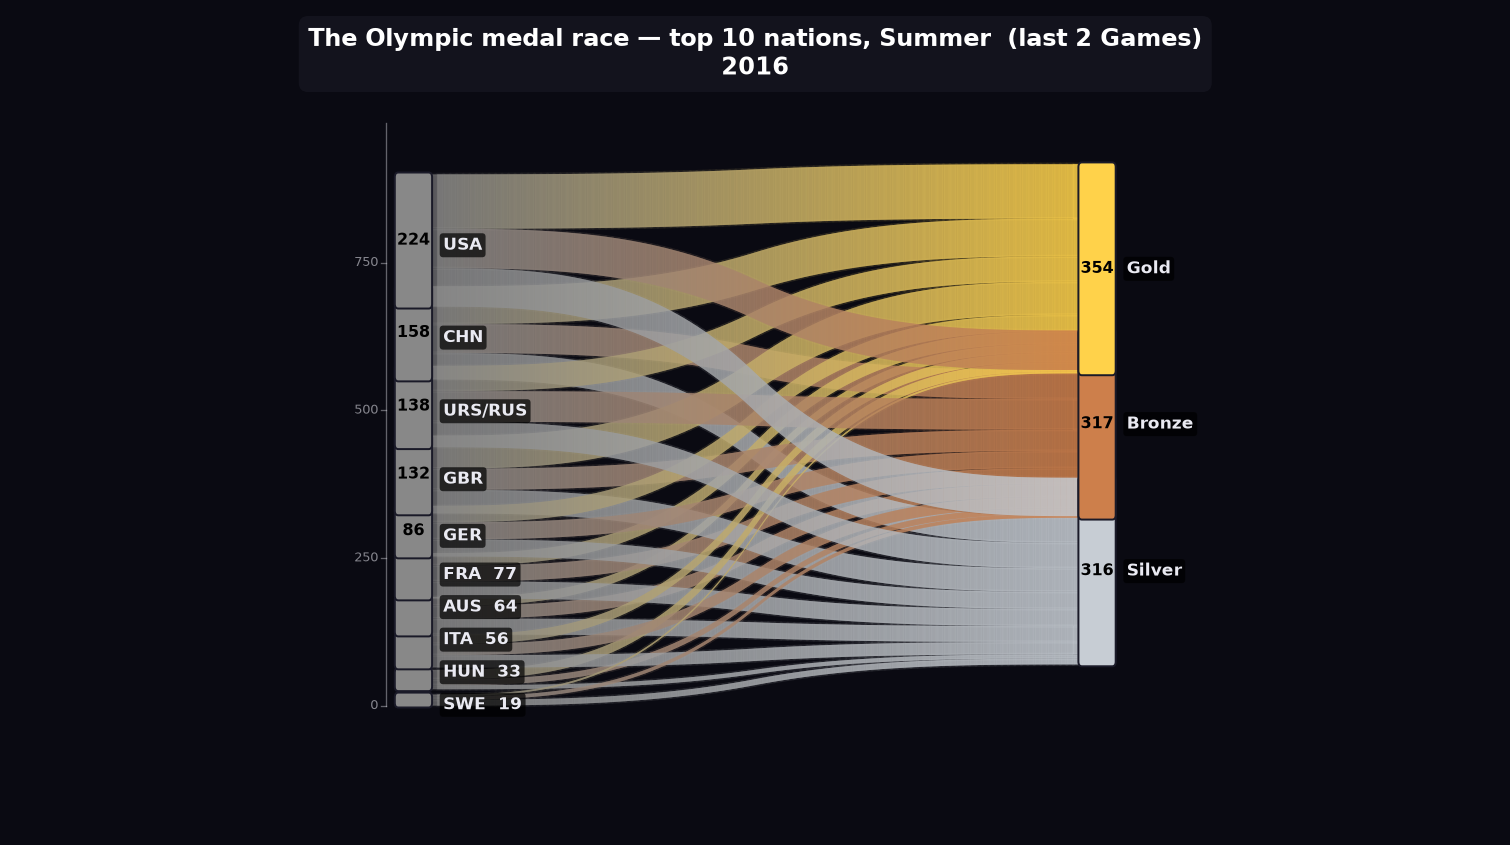

In [11]:
still_design = dict(
    figsize=(16, 9), dpi=95, font_size=13, title_fontsize=18, padding=2.8,
    margin_top=0.16, margin_bottom=0.22,
    ranking_mode=True, stacked_mode=True,            # the race: reorder AND resize
    theme="dark", link_glow=1, link_alpha=0.6, n_segments=100,
    yaxis_node=anchor, yaxis_suffix="",              # medal-count axis, scaled to the leader's window
    yaxis_gap=0.15, layer0_label_side="right",       # axis hugs the nations; names on the right
    value_prefix="",                                 # medals, not dollars (save_frame defaults to "$")
)

TITLE = f"The Olympic medal race — top {len(countries)} nations, {SEASON}  (last {ROLL} Games)"
year_to_index = {f["time_label"]: i for i, f in enumerate(sk.frames)}
still_paths = []
for yr in ("1976", "1980", "2016"):
    if yr not in year_to_index:
        continue
    p = os.path.join(ASSETS, f"olympics_{yr}.png")
    sk.save_frame(p, frame_index=year_to_index[yr], title=TITLE, **still_design)
    still_paths.append(p)
    print("saved", p)

for p in still_paths:
    display(show(p, w=1000))



### One short animation — *now* the rank colours come alive 🎬

A tiny clip to prove the motion **and** the dynamic colouring, with the **full** reel design: dark
theme, glow, the medal‑count axis, the growth overlay, the **beat captions + holds**, and — the
headline — **`dynamic_color_mode="ranking"` + `autumn_r`** with the medals pinned **metallic** via
`fixed_color_nodes`, so the #1 nation burns hot while the rest cool off. We keep it short for speed; the
cell **skips gracefully** if FFmpeg isn't installed.


In [12]:
sample_mp4 = os.path.join(ASSETS, "olympics_sample.mp4")
try:
    sk.animate(
        sample_mp4,
        figsize=(16, 9), fps=30, duration_seconds=10, quality="medium", n_workers=2,
        title=TITLE,
        font_size=13, title_fontsize=18, padding=2.8,
        margin_top=0.18, margin_bottom=0.22,
        ranking_mode=True, stacked_mode=True,
        dynamic_color_mode="ranking", dynamic_colormap="autumn_r",   # <-- the star: nations by live rank
        fixed_color_nodes=FIXED_COLOR_NODES,                          # ...medals stay metallic
        theme="dark", link_glow=1, link_alpha=0.6, n_segments=100,
        yaxis_node=anchor, yaxis_suffix="", yaxis_gap=0.15, layer0_label_side="right",
        value_prefix="",                                             # medals, not dollars
        annotations=annotations, hold_periods=hold_periods,          # 1980/84/92/2008 beats + pauses
        overlay_series=total, overlay_x_labels=xlabels,
        overlay_label=f"Medals of the top {len(countries)} nations — rolling {ROLL}-Games window",
        overlay_color="#FFD24A", overlay_value_suffix="", overlay_badge=f"{ROLL}-GAMES",
        overlay_band=(0.18, 0.56),                                   # push the line chart lower
    )
    from IPython.display import Video
    print("rendered:", sample_mp4)
    display(Video(sample_mp4, embed=True, width=900))
except Exception as e:
    print("Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.")
    print("Reason:", repr(e))


Settings (MULTI-LAYER PARALLEL):
  - Layers: 2
  - Nodes per layer: [10, 3]
  - FPS: 30, Duration: 10s
  - Quality: medium
  - Total frames: 300
  - Gradient segments: 100
  - Positioning mode: Stacked + Ranking
  - Dynamic color mode: Ranking
  - Colormap: autumn_r

Pre-computing 300 frames...


  Pre-computation: 2.12s
  Workers: 2

Rendering on 2 parallel processes...


Skipping the MP4 (FFmpeg likely not installed) — the stills above tell the story.
Reason: MemoryError((900, 1600, 3), dtype('uint8'))



## 12 · Recap & try it yourself

🎉 **You built the whole reel** — from a raw, one‑row‑per‑athlete CSV to an animated gradient Sankey
ranking race of nations that **recolours itself by rank** every frame, with no external project files.

**The pipeline, in one breath:** download `athlete_events.csv` (public GitHub raw, cached) → **drop
non‑medal rows** → **de‑duplicate to one medal per `(Games, Event, Medal, NOC)`** (the load‑bearing
step — *verified* USA golds ≈ 1,000) → **stitch** dissolved states (USSR→Russia, the two Germanys) →
keep the **top‑10** nations (drop the long tail) → build a **rolling 2‑Games window** (*not* cumulative,
so the race moves) → growth overlay → `from_dataframe` → `save_frame` stills + `animate` with
**`dynamic_color_mode="ranking"` + `autumn_r`**, **metallic medals** via `fixed_color_nodes`, and beat
**captions + holds** on 1980/1984/1992/2008.

### 💙 The honesty notes (what makes it trustworthy)

1. **De‑dup before counting.** One row per athlete per event would let a 12‑player basketball gold
   count as twelve — so we collapse to one physical medal per event‑place (verified vs USA golds).
2. **Stitch continuity, with a caveat.** USSR→Russia and the two Germanys become one line each so no
   nation *vanishes* for political reasons — but fusing GDR+FRG folds the GDR‑doping era into Germany.
3. **Rolling, not cumulative.** A running total can only grow and freezes dead empires at their peak; a
   rolling 2‑Games window lets the USSR collapse and China surge.

### 🧪 Try it yourself

1. **A wider field.** Raise `TOP` to 12–15 in §6 — more nations, more baton‑passing in the race.
2. **A different window.** Set `ROLL = 1` (each single Games) or `ROLL = 3` (~12‑yr form) in §7 — note
   `ROLL = 1` *zeros out* boycotting nations (USA 1980, the Soviet bloc 1984).
3. **Cumulative comparison.** Swap the `rolling(...)` line in §7 for a `cumsum` and watch the race go
   flat — a great way to *feel* why we chose the rolling window.
4. **A different colormap.** Swap `dynamic_colormap="autumn_r"` for `"plasma"`, `"turbo"`, or
   `"inferno"` in the clip — same ranking logic, new mood. (The metallic medals stay put.)
5. **Golds only.** Filter `df` to `medal == "Gold"` for a *gold‑medal* race — the right column collapses
   to one node and the story sharpens to outright wins.

### 🔗 Links

- The library: `gradient_sankey.py` (repo root) · `pip install gradient-sankey`
- The dataset — *120 years of Olympic history* (free, no API key):
  https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results
- The public CSV mirror used here:
  https://raw.githubusercontent.com/Thomas-George-T/Olympic-History-Analytics-in-R/main/athlete_events.csv
- Companion tutorials: `notebooks/06_tutorial_refugees.ipynb`, `notebooks/04_tutorial_co2.ipynb`,
  `notebooks/03_tutorial_energy.ipynb`

> 💡 Remember the lessons that make this reel **honest**: de‑duplicate to one medal per
> `(Games, Event, Medal, NOC)` before counting, **stitch** dissolved states so nations don't vanish, and
> use a **rolling window** (not a cumulative tally) so the race actually moves. `dynamic_color_mode="ranking"`,
> `fixed_color_nodes`, `annotations`/`hold_periods`, the medal axis (`value_prefix=""`), `yaxis_gap`,
> `layer0_label_side` and `overlay_band` are available in **this local copy** — check your installed
> `gradient-sankey` version if any are missing. Importing the local module via `sys.path` (as in §1)
> makes everything just work. 💙

*Built com todo cuidado e carinho. Data: 120 years of Olympic history (free, no API key). Happy hacking!*
